# Data Download: Andes Centrales, Región Metropolitana, Chile

**Study Area**: Andes Centrales, Región Metropolitana, Chile

**Priority**: HIGH

**Expected Results**:
- DEM tiles: ~2 tiles (~100 MB)
- Sentinel-2 scenes: ~24 files (8 years × 3 bands, 2017-2024, ~8 GB)
- Lake count: 100 glacial lakes
- GLOF events: 3 documented events

**Bounding Box**: [-70.0, -33.5, -69.5, -33.0] (WGS84)

**EPSG**: 32719 (UTM Zone 19S)

## 1. Setup and Configuration

In [1]:
# Core libraries
import sys
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Geospatial libraries
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from shapely.geometry import box
import numpy as np

# Planetary Computer
import pystac_client
import planetary_computer

# Visualization
import matplotlib.pyplot as plt

# Progress bar
from tqdm.auto import tqdm

print("Libraries imported successfully")
print(f"Execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Import download utility
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import and reload shared download functions
import importlib
import src.download
importlib.reload(src.download)
from src.download import download_study_area_data
from config_expanded_study_areas import EXPANDED_STUDY_AREAS

Libraries imported successfully
Execution started: 2026-03-28 01:14:22


## 2. Execute Download

Usando TODOS los años disponibles: 2017-2025 (9 años)
  GLOF Project >> ANDES CENTRALES, REGIÓN METROPOLITANA, CHILE
  Bbox: [-70.0, -33.5, -69.5, -33.0]  |  EPSG:32719
  ~100 lagunas  |  3 GLOFs documentados
  Serie temporal: 2017–2025 (9 años)  |  Bandas: B02 B03 B04 B08 B11 B12

[DEM] NASADEM 30m
  [ok] NASADEM_HGT_s34w071  (0.0 MB, existente)
  [ok] NASADEM_HGT_s34w070  (5.7 MB, existente)
  [dl] NASADEM_HGT_s33w071 [3/4]... ok (0.0 MB)
  [dl] NASADEM_HGT_s33w070 [4/4]... ok (0.0 MB)
  Total: 4 tile(s)

[Sentinel-2 L2A] Temporada seca: meses [6, 7, 8]  |  nubosidad < 15%
  [ok] 2017  2017-06-30  cloud:2.8%  [B02 B03 B04 B08 B11 B12]  2.1 MB  (existentes)
  [ok] 2018  2018-08-09  cloud:2.3%  [B02 B03 B04 B08 B11 B12]  2.1 MB  (existentes)
  [ok] 2019  2019-07-15  cloud:2.7%  [B02 B03 B04 B08 B11 B12]  2.2 MB  (existentes)
  [ok] 2020  2020-08-03  cloud:1.4%  [B02 B03 B04 B08 B11 B12]  2.1 MB  (existentes)
  [ok] 2021  2021-06-02  cloud:1.6%  [B02 B03 B04 B08 B11 B12]  16.2 MB  (exis

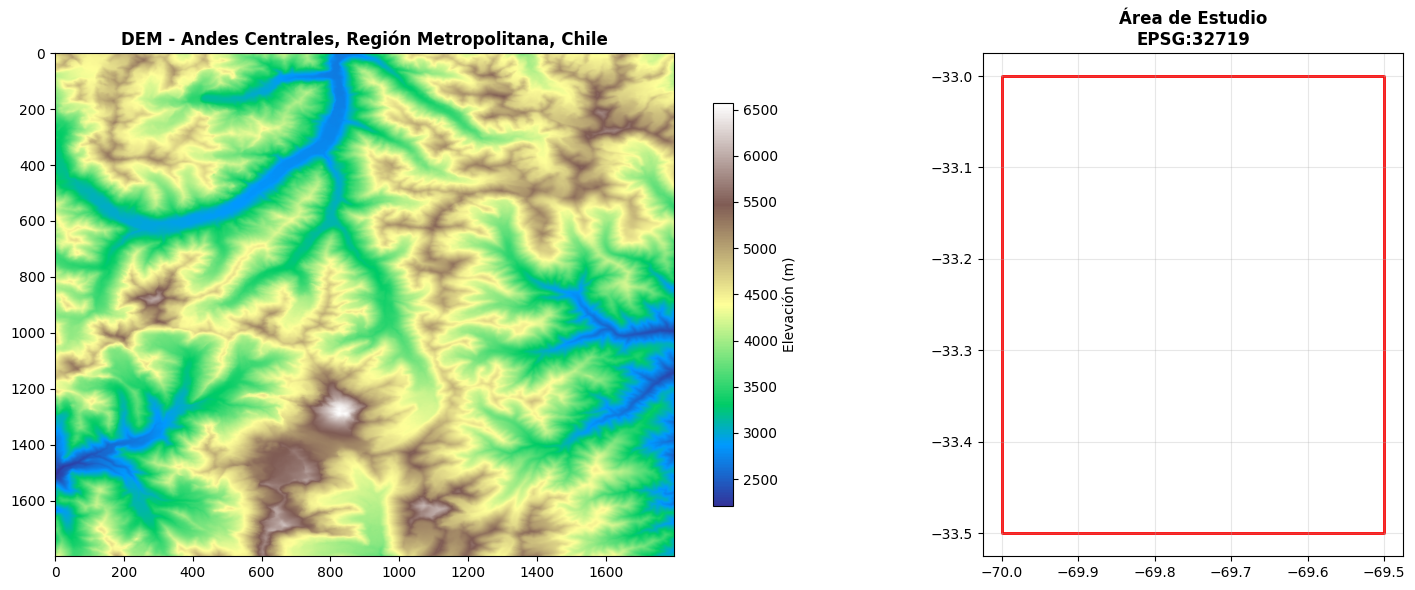

  Visualización guardada: /home/andre/Documents/GLOF_Andes_Project-Paper/figures/downloads/download_chile_andes_centrales.png
  Metadatos: /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_chile_andes_centrales.json
DESCARGA COMPLETADA EXITOSAMENTE

DOWNLOAD COMPLETE
Total data downloaded: 0.33 GB
DEM tiles: 4
Sentinel-2 years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Metadata saved to: /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_chile_andes_centrales.json


In [2]:
# Study area configuration
area_name = 'chile_andes_centrales'

# Execute download
# years=None: Uses ALL available years (2017-2025 = 9 years)
# This provides stronger temporal analysis for Nature Geoscience publication
results = download_study_area_data(
    area_name=area_name,
    years=None,  # ALL available years: 2017-2025 (9 years)
    months=[6, 7, 8],  # Dry season
    sentinel_bands=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'],
    max_cloud_cover=15,
    visualize=True,
    save_metadata=True
)

if results['success']:
    print("\n" + "=" * 80)
    print("DOWNLOAD COMPLETE")
    print("=" * 80)
    print(f"Total data downloaded: {results['total_size_gb']:.2f} GB")
    print(f"DEM tiles: {results['dem_tiles']}")
    print(f"Sentinel-2 years: {results['sentinel_years']}")
    print(f"Metadata saved to: {results['metadata_path']}")
    print("=" * 80)
else:
    print("[ERROR] Download failed. Check error messages above.")
    raise RuntimeError(f"Download failed for {area_name}")

---
## Resumen Global de Descargas — 10 Áreas de Estudio

Verifica que los 10 notebooks de descarga completaron correctamente.
Ejecuta esta celda tras completar el NB09.

In [3]:
import json, glob
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
meta_dir = project_root / 'data' / 'raw'

print("=" * 80)
print("RESUMEN GLOBAL DE DESCARGAS — PAN-ANDEAN GLOF PROJECT")
print("=" * 80)

areas_ok = []
areas_warn = []

for meta_path in sorted(meta_dir.glob('metadata_*.json')):
    with open(meta_path) as f:
        d = json.load(f)

    area     = d.get('area_name', meta_path.stem)
    dem_n    = d.get('dem_tiles', 0)
    s2_years = sorted(d.get('sentinel_years', []))
    n_years  = len(s2_years)
    sf       = d.get('sentinel_files', {})
    
    # Cloud cover stats
    covers = [sf[str(y)]['cloud_cover'] for y in s2_years if str(y) in sf]
    cc_max  = max(covers) if covers else 0
    cc_mean = sum(covers) / len(covers) if covers else 0
    
    # File count
    s2_dir = project_root / 'data' / 'raw' / 'sentinel2' / area
    n_files = len(list(s2_dir.rglob('*.tif'))) if s2_dir.exists() else 0
    
    missing = [y for y in range(2017, 2026) if y not in s2_years]
    status  = "OK" if n_years == 9 else f"WARN ({9 - n_years} años faltan)"
    
    print(f"\n  {area}")
    print(f"    DEM tiles : {dem_n}")
    print(f"    S2 años   : {n_years}/9  {s2_years}")
    print(f"    S2 archivos: {n_files} (esperado: 54)")
    print(f"    Nube media: {cc_mean:.1f}%  máx: {cc_max:.1f}%")
    if missing:
        print(f"    FALTAN    : {missing}")
        areas_warn.append(area)
    else:
        areas_ok.append(area)

print()
print("=" * 80)
print(f"Áreas completas (9/9 años)  : {len(areas_ok):2d} / 10")
print(f"Áreas con años faltantes    : {len(areas_warn):2d} / 10")

# Totals
total_s2 = sum(
    len(list((project_root / 'data' / 'raw' / 'sentinel2' / a).rglob('*.tif')))
    for a in [m.stem.replace('metadata_','') for m in sorted(meta_dir.glob('metadata_*.json'))]
)
total_dem = len(list((project_root / 'data' / 'raw' / 'dem').rglob('*.tif')))
size_s2_gb = sum(
    f.stat().st_size for f in (project_root / 'data' / 'raw' / 'sentinel2').rglob('*.tif')
) / 1e9
size_dem_mb = sum(
    f.stat().st_size for f in (project_root / 'data' / 'raw' / 'dem').rglob('*.tif')
) / 1e6

print()
print(f"Total archivos S2  : {total_s2}  (~{size_s2_gb:.1f} GB)")
print(f"Total tiles DEM    : {total_dem}  (~{size_dem_mb:.0f} MB)")
print()
if not areas_warn:
    print("[SUCCESS] Todas las áreas tienen datos completos. Listo para NB11.")
else:
    print(f"[WARNING] Áreas incompletas: {areas_warn}")
print("=" * 80)


RESUMEN GLOBAL DE DESCARGAS — PAN-ANDEAN GLOF PROJECT

  bolivia_cordillera_real
    DEM tiles : 2
    S2 años   : 9/9  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    S2 archivos: 54 (esperado: 54)
    Nube media: 0.0%  máx: 0.1%

  chile_andes_centrales
    DEM tiles : 4
    S2 años   : 9/9  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    S2 archivos: 54 (esperado: 54)
    Nube media: 1.2%  máx: 2.8%

  cordillera_blanca
    DEM tiles : 2
    S2 años   : 9/9  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    S2 archivos: 54 (esperado: 54)
    Nube media: 0.6%  máx: 1.8%

  cordillera_central
    DEM tiles : 4
    S2 años   : 9/9  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    S2 archivos: 54 (esperado: 54)
    Nube media: 0.6%  máx: 4.3%

  cordillera_huanzo
    DEM tiles : 4
    S2 años   : 9/9  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    S2 archivos: 54 (esperado: 54)
    Nube media: 0.6%  máx: 1.2%

  cordillera_huayhuash
 